<a href="https://colab.research.google.com/github/Azizov7Ycd/Machine-Learning-with-Scikit-Learn-and-Pytorch/blob/main/Chapter17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing the necessary libraries
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
# Looking at the torch version
print(torch.__version__)

2.11.0+cpu


In [ ]:
# Looking if GPU is available
# torch.cuda.is_available()
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # Do not forget the torch device
print(device)

cuda


In [ ]:
# Building generator and discriminator parts of GAN
# Building the generator
def make_generator(input_size=20,number_hidden_units=100,num_hidden_layers=1,num_output_units=784):
      generator=nn.Sequential()
      for i in np.arange(num_hidden_layers):
          generator.add_module(f'fc{i}',nn.Linear(input_size,number_hidden_units))    # 20 input units as well as 100 hidden units
          generator.add_module(f'l_relu{i}',nn.LeakyReLU(negative_slope=0.2))
          input_size=number_hidden_units
      generator.add_module(f'fc{number_hidden_units}',nn.Linear(number_hidden_units,num_output_units))   # 100 hidden units as well as 784 output units (pixels)
      generator.add_module('tahn',nn.Tanh())
      return generator

In [ ]:
# Building the discrimator
def make_discriminator(input_size,num_hidden_layers=1,num_hidden_units=100,num_output_units=1):
  discriminator=nn.Sequential()
  for i in np.arange(num_hidden_layers):
    discriminator.add_module(f'fc{i}',nn.Linear(input_size,num_hidden_units,bias=False))
    discriminator.add_module(f'leakyReLU{i}',nn.LeakyReLU(negative_slope=0.2))
    discriminator.add_module(f'drop{i}',nn.Dropout(p=0.5))
    input_size=num_hidden_units
  discriminator.add_module(f'fc{num_hidden_units}',nn.Linear(num_hidden_units,num_output_units))
  discriminator.add_module('sigmoid',nn.Sigmoid())
  return discriminator

In [ ]:
# Initializing generator and discriminator
image_size=np.array([28,28])
z_size=20   # number of images to generate
gen_hidden_layers=1
gen_hidden_size=100
disc_hidden_layers=1
disc_hidden_size=100

# Defining generator model
generator=make_generator(input_size=z_size,num_hidden_layers=gen_hidden_layers,number_hidden_units=gen_hidden_size,num_output_units=np.prod(image_size))
print(generator)

# Defining discriminator model
discriminator=make_discriminator(input_size=np.prod(image_size),num_hidden_layers=disc_hidden_layers,num_hidden_units=disc_hidden_size)
print(discriminator)


Sequential(
  (fc0): Linear(in_features=20, out_features=100, bias=True)
  (l_relu0): LeakyReLU(negative_slope=0.2)
  (fc100): Linear(in_features=100, out_features=784, bias=True)
  (tahn): Tanh()
)
Sequential(
  (fc0): Linear(in_features=784, out_features=100, bias=False)
  (leakyReLU0): LeakyReLU(negative_slope=0.2)
  (drop0): Dropout(p=0.5, inplace=False)
  (fc100): Linear(in_features=100, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [ ]:
# Importing torchvision
import torchvision
from torchvision.transforms import v2

image_path=Path(r'./')
# Initializing the transformer object
transform=v2.Compose([v2.ToImage(),v2.ToDtype(torch.float32,scale=True),v2.Normalize((0.5,),(0.5,))])

# Downloading the dataset
dataset=torchvision.datasets.MNIST(root=image_path,train=True,transform=transform,download=True)

# Iterating through the dataset
example,label=next(iter(dataset))
print(label)
print(example.shape)  # (1,28,28)
print(example.max()-example.min())

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.45MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]

5
torch.Size([1, 28, 28])
tensor(2.)


In [ ]:
# Creating noise z for generator
def create_noise(mode_z,batch_size,z_size):
  if mode_z=='normal':
    input_z=torch.randn(batch_size,z_size)
  elif mode_z=='uniform':
    input_z=torch.rand(batch_size,z_size)*2-1
  return input_z


In [ ]:
# Importing and initializing the dataloader
from torch.utils.data import DataLoader
batchsize=32
dataloader=DataLoader(dataset,batch_size=batchsize,shuffle=False)

# Taking the first input and label from the dataloader
img,label=next(iter(dataloader))
# Flattening the images using .view() method
input_real=img.view(batchsize,-1)   # done to keep the first dimension of both real and generated data the same  (32,784)

# Creating generated input
torch.manual_seed(11)
input_z=create_noise('uniform',batch_size=32,z_size=20)
# Printing the shape for the inputs
print('input_z--shape',input_z.shape)
print('input_real--shape',input_real.shape)

# Generating the output from the model
g_output=generator(input_z)
print('Shape of generated output', g_output.shape)

# Putting the inputs into discriminator
d_real_proba=discriminator(input_real)
d_gener_proba=discriminator(g_output)
print('Dis real--shape',d_real_proba.shape)
print('Dis generated--shape',d_gener_proba.shape)

input_z--shape torch.Size([32, 20])
input_real--shape torch.Size([32, 784])
Shape of generated output torch.Size([32, 784])
Dis real--shape torch.Size([32, 1])
Dis generated--shape torch.Size([32, 1])


In [ ]:
# For generator d_probafake containing all 1s
# For discriminator there are two terms: d_proba_fake and d_proba_real
loss_fn=nn.BCELoss()
# Loss for the Generator
g_labels_real=torch.ones_like(d_gener_proba)
generator_loss=loss_fn(d_gener_proba,g_labels_real)
print(f"Generator Loss. {generator_loss:.4f}")

# Loss for the Discriminator
d_labels_real=torch.ones_like(d_real_proba) # assigning 1 to real inputs
d_labels_fake=torch.zeros_like(d_gener_proba) # assigning 0 to fake inputs
# Computing real and fake loses
d_loss_real=loss_fn(d_real_proba,d_labels_real)
d_loss_fake=loss_fn(d_gener_proba,d_labels_fake)
# Printing real and fake loss
print(f'Discriminator Loss Real:{d_loss_real:.4f}, Fake: {d_loss_fake:.4f}')


Generator Loss. 0.7361
Discriminator Loss Real:0.8688, Fake: 0.6523


In [ ]:
# Building the data loader as well as trainer and discriminator models
batch_size=64
torch.manual_seed(1)
np.random.seed(44)
# Setting the dataloader
mnist_dl=DataLoader(dataset,batch_size=64,shuffle=True,drop_last=True)

# Setting generator
gen_model=make_generator(input_size=20,num_hidden_layers=1,number_hidden_units=100,num_output_units=784).to(device)
# Setting discriminator
disc_model=make_discriminator(input_size=784,num_hidden_layers=1,num_hidden_units=100).to(device)


In [ ]:
# Determining loss function and optimizers
loss_fn=nn.BCELoss()
g_optimizer=torch.optim.Adam(gen_model.parameters(),lr=0.001)
d_optimizer=torch.optim.Adam(disc_model.parameters(),lr=0.001)

In [ ]:
# Training the discriminator
def d_train(batch):
  # Setting gradients to 0
  disc_model.zero_grad()
  # Training discriminator with the real batch
  batch_size=batch.size(0)
  # Setting to [batch_size,784]
  batch=batch.view(batch_size,-1).to(device)
  # Setting 1 to the real labels
  d_labels_real=torch.ones(batch_size,1).to(device)
  # Calculating the discriminator probabilitoes
  d_proba_real=disc_model(batch)
  # Calculating real loss
  d_loss_real=loss_fn(d_proba_real,d_labels_real)

  # Training discriminator on fake batches
  input_z=create_noise(batch_size=64,z_size=20,mode_z='uniform').to(device)
  g_output=gen_model(input_z)
  # Discriminator determines the fake probability
  d_proba_fake=disc_model(g_output)
  d_labels_fake=torch.zeros(batch_size,1).to(device)
  d_loss_gener=loss_fn(d_proba_fake,d_labels_fake)
  # Gradient backpropagation and optimizing
  d_loss=d_loss_real+d_loss_gener
  d_loss.backward()
  d_optimizer.step()
  return d_loss.detach().item(), d_proba_real.detach(), d_proba_fake.detach()

In [ ]:
# Training the generator
def g_train(batch):
  gen_model.zero_grad()
  batch_size=batch.size(0)
  # Creating noise
  input_z=create_noise(batch_size=64,z_size=20,mode_z='uniform').to(device)
  # Setting 1 as real labels
  g_labels_real=torch.ones(batch_size,1).to(device)
  # Using generator to create input for discriminator
  g_output=gen_model(input_z)
  d_proba_fake=disc_model(g_output)
  # Calculating loss and backpropagating it
  g_loss=loss_fn(d_proba_fake,g_labels_real)
  g_loss.backward()
  g_optimizer.step()
  return g_loss.detach().item()

In [ ]:
# Creating the training loop
fixed_z=create_noise(batch_size=64,z_size=20,mode_z='normal').to(device)
# Defining function for sample creation
def create_samples(g_model,input_z):
  g_output=g_model(input_z)
  images=torch.reshape(g_output,(64,28,28))
  return (images+1.0)/2.0

epoch_samples=[]
all_d_losses=[]
all_g_losses=[]
all_d_real=[]
all_d_fake=[]
num_epochs=100

for epoch in range(1,num_epochs+1):
  d_losses,g_losses=[],[]
  d_vals_real,d_vals_fake=[],[]
  for i,(x,_) in enumerate(mnist_dl):  # i, (input,label)
    d_loss,d_proba_real,d_proba_fake=d_train(x)
    d_losses.append(d_loss)
    d_vals_real.append(d_proba_real.mean().cpu())
    d_vals_fake.append(d_proba_fake.mean().cpu())
    g_losses.append(g_train(x))
  # Calculating the mean loss per batch
  all_d_losses.append(torch.tensor(d_losses).mean())
  all_g_losses.append(torch.tensor(g_losses).mean())
  all_d_real.append(torch.tensor(d_vals_real).mean())
  all_d_fake.append(torch.tensor(d_vals_fake).mean())
  # Printing the reult
  print(f'Epoch:{epoch}, Avg Losses G/D: {all_g_losses[-1]:.4f}/{all_d_losses[-1]:.4f}, D-Real: {all_d_real[-1]:.4f}, D-Fake: {all_d_fake[-1]:.4f}')
  samp=create_samples(gen_model,fixed_z)
  epoch_samples.append(samp.detach().cpu().numpy())

Epoch:1, Avg Losses G/D: 1.3539/0.6850, D-Real: 0.8818, D-Fake: 0.3802
Epoch:2, Avg Losses G/D: 1.3983/0.8933, D-Real: 0.7654, D-Fake: 0.3762
Epoch:3, Avg Losses G/D: 1.4833/0.9214, D-Real: 0.7286, D-Fake: 0.3382
Epoch:4, Avg Losses G/D: 1.3059/1.0108, D-Real: 0.6817, D-Fake: 0.3467
Epoch:5, Avg Losses G/D: 1.2647/1.0771, D-Real: 0.6495, D-Fake: 0.3598
Epoch:6, Avg Losses G/D: 1.0675/1.1893, D-Real: 0.6018, D-Fake: 0.4008
Epoch:7, Avg Losses G/D: 1.1162/1.1676, D-Real: 0.6078, D-Fake: 0.3894
Epoch:8, Avg Losses G/D: 1.0636/1.2086, D-Real: 0.5910, D-Fake: 0.4023
Epoch:9, Avg Losses G/D: 1.0842/1.2240, D-Real: 0.5875, D-Fake: 0.4047
Epoch:10, Avg Losses G/D: 0.9051/1.3144, D-Real: 0.5449, D-Fake: 0.4464
Epoch:11, Avg Losses G/D: 0.9017/1.3143, D-Real: 0.5448, D-Fake: 0.4470
Epoch:12, Avg Losses G/D: 0.9454/1.2823, D-Real: 0.5586, D-Fake: 0.4356
Epoch:13, Avg Losses G/D: 0.9174/1.3013, D-Real: 0.5510, D-Fake: 0.4417
Epoch:14, Avg Losses G/D: 0.8978/1.3033, D-Real: 0.5477, D-Fake: 0.4464
E

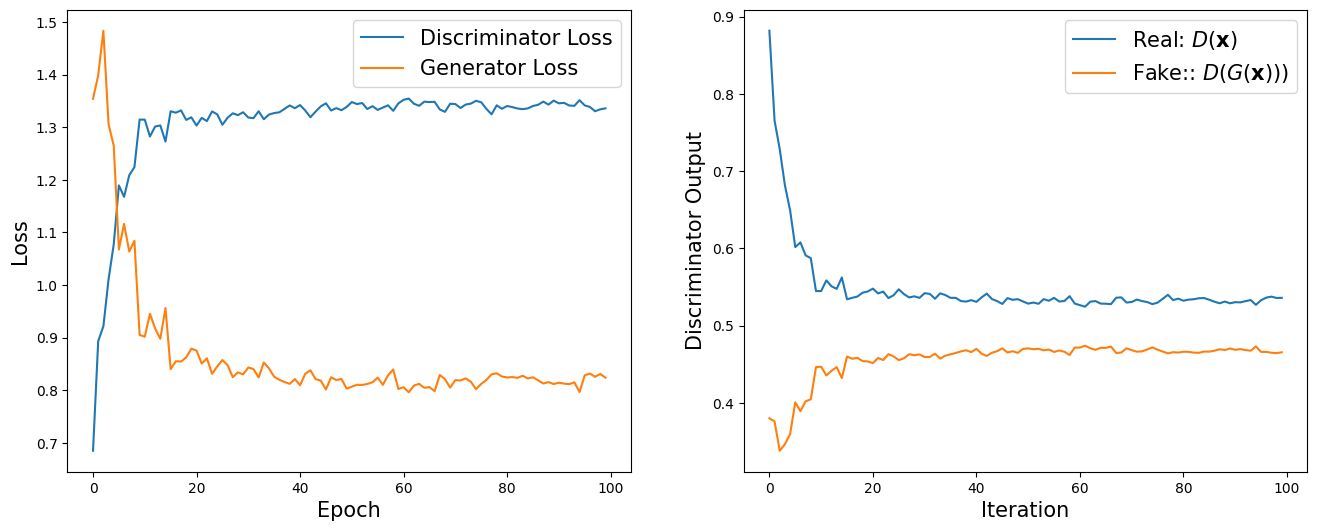

In [ ]:
import itertools
# Plotting the losses
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(16,6))
ax=ax.flatten()
ax[0].plot(all_d_losses,label='Discriminator Loss')
ax[0].plot(all_g_losses,label='Generator Loss')
ax[0].legend(fontsize=15)
ax[0].set_xlabel('Epoch',size=15)
ax[0].set_ylabel('Loss',size=15)
# Plotting the outputs of discriminator
ax[1].plot(all_d_real,label=r'Real: $D(\mathbf{x})$')     # $ For LaTex symbols (raw string necessary)
ax[1].plot(all_d_fake,label=r'Fake:: $D(G(\mathbf{x})))$')  # \ for LaTex commands
ax[1].legend(fontsize=15)
ax[1].set_xlabel('Iteration',size=15)
ax[1].set_ylabel('Discriminator Output',size=15)
plt.show()

In [ ]:
# Printing some generated images
selected_epochs=[1,2,4,10,50,100]
fig=plt.figure(figsize=(10,14))
for i,e in enumerate(selected_epochs):
  for j in range(5):
    ax=fig.add_subplot(6,5,i*5+j+1)    # last position is index
    # no ticks
    ax.set_xticks([])
    ax.set_yticks([])
    if j==0:
      ax.text(-0.06,0.5,f'Epoch {e}',rotation=90,size=18,color='red',horizontalalignment='right',verticalalignment='center',transform=ax.transAxes)
    image=epoch_samples[e-1][j]
    ax.imshow(image,cmap='gray')
plt.show()

NameError: name 'ax' is not defined

# Deep Convolutional GAN

In [ ]:
class Generator(nn.Module):
    def __init__(self, n_filters, input_channels):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(input_channels, n_filters*4, 4, 1, 0, bias=False),  # 1  -> 4
            nn.BatchNorm2d(n_filters*4),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(n_filters*4, n_filters*2, 3, 2, 1, bias=False),     # 4  -> 7
            nn.BatchNorm2d(n_filters*2),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(n_filters*2, n_filters, 4, 2, 1, bias=False),       # 7  -> 14
            nn.BatchNorm2d(n_filters),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(n_filters, 1, 4, 2, 1, bias=False),                 # 14 -> 28
            nn.Tanh(),
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
# Creating a discriminator class
class Discriminator(nn.Module):
      def __init__(self, n_filters):
        super().__init__()
        self.network = nn.Sequential(nn.Conv2d(1, n_filters, 4, 2, 1, bias=False),
                                     nn.LeakyReLU(0.2),
                                     nn.Conv2d(n_filters, n_filters*2,4, 2, 1, bias=False),
                                     nn.BatchNorm2d(n_filters * 2),
                                     nn.LeakyReLU(0.2),
                                     nn.Conv2d(n_filters*2, n_filters*4,3, 2, 1, bias=False),
                                     nn.BatchNorm2d(n_filters*4),
                                     nn.LeakyReLU(0.2),
                                     nn.Conv2d(n_filters*4, 1, 4, 1, 0, bias=False),
                                     nn.Sigmoid())
      def forward(self,x):
        output=self.network(x)
        return output.view(-1,1).squeeze(0)


In [ ]:
# Initializing generator and discriminator
z_size=100
image_size=(28,28)
n_filters=32
gen_model=Generator(input_channels=z_size,n_filters=n_filters).to(device)
print(gen_model)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)


In [ ]:
# Printing discriminator model
disc_model=Discriminator(n_filters).to(device)
print(disc_model)


Discriminator(
  (network): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(128, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (9): Sigmoid()
  )
)


In [ ]:
# Specifying loss function and optimizer
loss_fn=nn.BCELoss()
g_optimizer=torch.optim.Adam(gen_model.parameters(),lr=0.0003)
d_optimizer=torch.optim.Adam(disc_model.parameters(),lr=0.0002)

In [ ]:
# Creating noise
def create_noise(batch_size,z_size,mode_z):
  if mode_z=='normal':
    input_z=torch.randn(batch_size,z_size,1,1)    # the shape requirements for nn.ConvTranspose2d(n_batches,c_in,height,width)
  if mode_z=='uniform':
    input_z=torch.rand(batch_size,z_size,1,1)*2-1
  return input_z

In [ ]:
# What needs to be put onto device => model, each batch, labels and targets
# Creating a training function
def d_train(x):
  disc_model.zero_grad()
  # Train the discriminator with a real batch
  batch_size=x.size(0)
  x=x.to(device)
  d_labels_real=torch.ones(batch_size,1).to(device)
  d_proba_real=disc_model(x)
  loss_real=loss_fn(d_proba_real,d_labels_real).to(device)
  # Training discriminator on the fake batch
  z=create_noise(batch_size,z_size=100,mode_z='uniform').to(device)
  # Generating fake images
  g_output=gen_model(z)
  d_proba_fake=disc_model(g_output)
  # Assigning 0 to generated images
  d_labels_fake=torch.zeros(batch_size,1).to(device)
  loss_fake=loss_fn(d_proba_fake,d_labels_fake).to(device)
  # backpropagation and updating dradient parameters
  d_loss=loss_real+loss_fake
  d_loss.backward()
  d_optimizer.step()
  # Returning the the loss
  return d_loss.data.item(),d_proba_real.detach(),d_proba_fake.detach()

In [ ]:
# Training the generator
def g_train(batch):
  gen_model.zero_grad()
  batch_size=batch.size(0)
  # Creating noise
  # input_z=create_noise(batch_size=64,z_size=20,mode_z='uniform').to(device)
  # Setting 1 as real labels
  g_labels_real=torch.ones(batch_size,1).to(device)
  # Using generator to create input for discriminator
  g_output=gen_model(fixed_z)
  d_proba_fake=disc_model(g_output)
  # Calculating loss and backpropagating it
  g_loss=loss_fn(d_proba_fake,g_labels_real)
  g_loss.backward()
  g_optimizer.step()
  return g_loss.detach().item()

In [ ]:
# Building the data loader as well as trainer and discriminator models
from torch.utils.data import DataLoader
batch_size=64
torch.manual_seed(7)
# Setting the dataloader
mnist_dl=DataLoader(dataset,batch_size=64,shuffle=True,drop_last=True)

In [ ]:
len(mnist_dl)

937

In [ ]:
# Training loop
def create_samples(g_model,input_z):
  g_output=g_model(input_z)
  images=torch.reshape(g_output,(64,28,28))
  return (images+1.0)/2.0

fixed_z=create_noise(batch_size=64,z_size=100,mode_z='uniform').to(device)
num_epochs=100
epoch_samples=[]
d_losses=[]
g_losses=[]
torch.manual_seed(33)

# Quick validation check on generator output shape before training
with torch.no_grad():
    test_out = gen_model(fixed_z)
    print(f"Current Generator output shape: {test_out.shape}")
    if test_out.shape[2:] != (28, 28):
        print("WARNING: Generator output size is not 28x28. Update Generator in cell hqH3WGKqqiQ5 to output 28x28 before training!")

for epoch in range(1,num_epochs+1):

  gen_model.train()
  for i, (x,_) in enumerate(mnist_dl):
      d_loss,d_proba_real,d_proba_fake=d_train(x)
      d_losses.append(d_loss)
      g_losses.append(g_train(x))
  print(f'Epoch {epoch} | Avg Losses G/D {torch.FloatTensor(g_losses).mean():.4f}/{torch.FloatTensor(d_losses).mean():.4f}')
      # Creating the sample and appending result to the list
  gen_model.eval()
  epoch_samples.append(create_samples(gen_model,fixed_z).detach().cpu().numpy())


Current Generator output shape: torch.Size([64, 1, 28, 28])
Epoch 1 | Avg Losses G/D 0.1080/0.0536
Epoch 2 | Avg Losses G/D 0.0542/0.0281
Epoch 3 | Avg Losses G/D 0.0361/0.0189
Epoch 4 | Avg Losses G/D 0.0271/0.0143
Epoch 5 | Avg Losses G/D 0.0217/0.0115
Epoch 6 | Avg Losses G/D 0.0181/0.0096
Epoch 7 | Avg Losses G/D 0.0155/0.0082
Epoch 8 | Avg Losses G/D 0.0136/0.0072
Epoch 9 | Avg Losses G/D 0.0120/0.0064
Epoch 10 | Avg Losses G/D 0.0108/0.0057
Epoch 11 | Avg Losses G/D 0.0099/0.0052
Epoch 12 | Avg Losses G/D 0.0090/0.0048
Epoch 13 | Avg Losses G/D 0.0083/0.0044
Epoch 14 | Avg Losses G/D 0.0077/0.0041
Epoch 15 | Avg Losses G/D 0.0072/0.0038
Epoch 16 | Avg Losses G/D 0.0068/0.0036
Epoch 17 | Avg Losses G/D 0.0064/0.0034
Epoch 18 | Avg Losses G/D 0.0060/0.0032
Epoch 19 | Avg Losses G/D 0.0057/0.0030
Epoch 20 | Avg Losses G/D 0.0054/0.0029
Epoch 21 | Avg Losses G/D 0.0052/0.0027
Epoch 22 | Avg Losses G/D 0.0049/0.0026
Epoch 23 | Avg Losses G/D 0.0047/0.0025
Epoch 24 | Avg Losses G/D 0.0

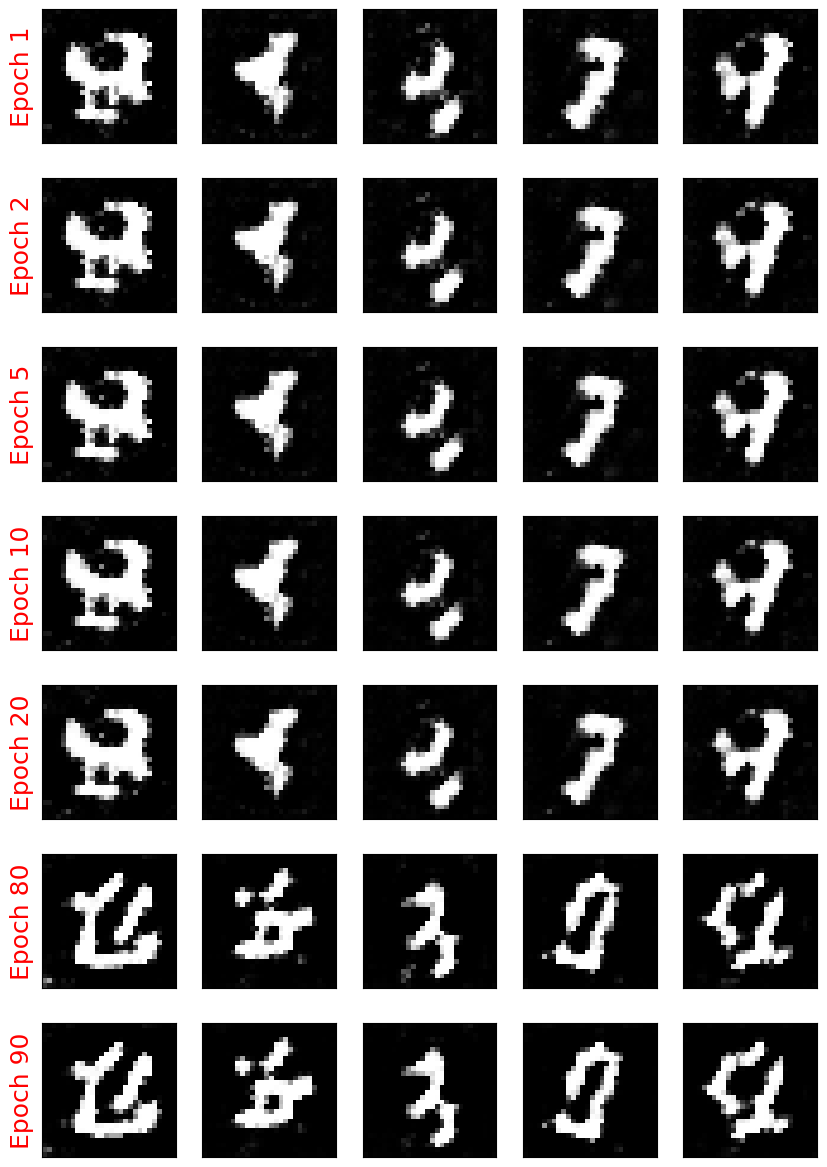

In [ ]:
selected_epoch=[1,2,5,10,20,80,90]
fig=plt.figure(figsize=(10,15))
for i,e in enumerate(selected_epoch):
   for j in range(5):
      ax=fig.add_subplot(7,5,i*5+j+1)
      ax.set_xticks([])
      ax.set_yticks([])
      if j==0:
        ax.text(-0.06,0.5,f'Epoch {e}',rotation=90,size=18,color='red',horizontalalignment='right',verticalalignment='center',transform=ax.transAxes)
      # Selecting the right images
      image=epoch_samples[e-1][j]
      ax.imshow(image,cmap='gray')
plt.show()

# Wasserstein GAN

In [ ]:
def make_generator_wgan(input_size,n_filters):
   model=nn.Sequential(nn.ConvTranspose2d(input_size,n_filters*4,4,1,0,bias=False),
                      nn.InstanceNorm2d(n_filters*4),
                      nn.LeakyReLU(0.2),
                      nn.ConvTranspose2d(n_filters*4,n_filters*2,3,2,1,bias=False),
                      nn.InstanceNorm2d(n_filters*2),
                      nn.LeakyReLU(0.2),
                      nn.ConvTranspose2d(n_filters*2,n_filters,4,2,1,bias=False),
                      nn.InstanceNorm2d(n_filters),
                      nn.LeakyReLU(0.2),
                      nn.ConvTranspose2d(n_filters,1,4,2,1,bias=False),
                      nn.Tanh())

   return model

In [ ]:
# Creating a discriminator using Sequential class
def discriminator_wgan(n_filters):
    discriminator=nn.Sequential(nn.Conv2d(in_channels=1,out_channels=n_filters,kernel_size=4,stride=2,padding=1,bias=False),
                                nn.LeakyReLU(0.2),
                                nn.Conv2d(in_channels=n_filters,out_channels=n_filters*2,kernel_size=4,stride=2,padding=1,bias=False),
                                nn.InstanceNorm2d(n_filters*2),
                                nn.LeakyReLU(0.2),
                                nn.Conv2d(in_channels=n_filters*2,out_channels=n_filters*4,kernel_size=3,stride=2,padding=1,bias=False),
                                nn.InstanceNorm2d(n_filters*4),
                                nn.LeakyReLU(0.2),
                                nn.Conv2d(in_channels=n_filters*4,out_channels=1,kernel_size=4,stride=1,padding=0,bias=False),
                                nn.Sigmoid())
    return discriminator



In [ ]:
# Creating generator and discriminator models
z_size=100
image_size=(28,28)
n_filters=32
batch_size=64

gen_model=make_generator_wgan(input_size=z_size,n_filters=n_filters).to(device)
disc_model=discriminator_wgan(n_filters=n_filters).to(device)

g_optimizer=torch.optim.Adam(gen_model.parameters(),lr=0.0002)
d_optimizer=torch.optim.Adam(disc_model.parameters(),lr=0.0002)

In [ ]:
from torch.autograd import grad as torch_grad
def gradient_penalty(real_data,generated_data,lambda_gp):
     batch_size=real_data.size(0)
     # Calculate interpolation
     alpha=torch.randn(real_data.shape[0],1,1,1,requires_grad=True).to(device)
     interpolated=alpha*real_data + (1-alpha)*generated_data
     # Calculate the probability of interpolated examples
     proba_interpolated=disc_model(interpolated)
     # Calculate gradients of probabilities
     gradients=torch_grad(outputs=proba_interpolated,inputs=interpolated,grad_outputs=torch.ones(proba_interpolated.size()).to(device),create_graph=True,retain_graph=True)[0]

     gradients=gradients.view(batch_size,-1)
     gradient_norm=gradients.norm(2,dim=1)
     return lambda_gp * ((gradient_norm-1)**2).mean()

In [ ]:
def create_noise(batch_size,z_size,mode_z):
  if mode_z=='normal':
    input_z=torch.randn(batch_size,z_size,1,1)
  if mode_z=='uniform':
     input_z=torch.rand(batch_size,z_size,1,1)**2-1
  return input_z

In [ ]:
# Defining training functions for discriminator
def d_train_wgan(x):
    disc_model.zero_grad()
    batch_size=x.shape[0]
    x=x.to(device)
    # Calculate probabilities on real and generated data
    d_real=disc_model(x)
    input_z=create_noise(batch_size=64,z_size=100,mode_z='uniform').to(device)
    g_output=gen_model(input_z)
    d_generated=disc_model(g_output)
    # Calculating Loss
    d_loss=d_generated.mean()-d_real.mean() + gradient_penalty(x.data,g_output.data,lambda_gp=10.0)
    d_loss.backward()
    d_optimizer.step()
    return d_loss.data.item()


In [ ]:
# Defining the function for generator
def g_train_wgan(x):
    gen_model.zero_grad()
    batch_size=x.size(0)
    input_z=create_noise(batch_size=64,z_size=100,mode_z='uniform').to(device)
    g_output=gen_model(input_z)

    d_generated=disc_model(g_output)
    g_loss=-d_generated.mean()
    # Gradient backprop and updating only g parameters
    g_loss.backward()
    g_optimizer.step()
    return g_loss.data.item()

In [ ]:
# Creating the training loop
fixed_z=create_noise(batch_size=64,z_size=20,mode_z='normal').to(device)
# Defining function for sample creation
def create_samples(g_model,input_z):
  g_output=g_model(input_z)
  images=torch.reshape(g_output,(64,28,28))
  return (images+1.0)/2.0

In [ ]:
# Creating a train loop
fixed_z=create_noise(batch_size=64,z_size=100,mode_z='normal').to(device)
epoch_samples_wgan=[]
num_epochs=100
torch.manual_seed(11)
critic_iterations=5
for epoch in range(1,num_epochs+1):
    gen_model.train()
    d_losses,g_losses=[],[]
    for i,(x,_) in enumerate(mnist_dl):
         for _ in range(critic_iterations):
                  d_loss=d_train_wgan(x)
         d_losses.append(d_loss)
         g_losses.append(g_train_wgan(x))
    print(f'Epoch {epoch} Loss {torch.FloatTensor(d_losses).mean():.4f}')
    gen_model.eval()
    epoch_samples_wgan.append(create_samples(gen_model,fixed_z).detach().cpu().numpy())

Epoch 1 Loss -0.5120
Epoch 2 Loss -0.5482
Epoch 3 Loss -0.6152
Epoch 4 Loss -0.5952
Epoch 5 Loss -0.6600
Epoch 6 Loss -0.6132
Epoch 7 Loss -0.7045
Epoch 8 Loss -0.6531
Epoch 9 Loss -0.7107
Epoch 10 Loss -0.7257
Epoch 11 Loss -0.6759
Epoch 12 Loss -0.6648
Epoch 13 Loss -0.6762
Epoch 14 Loss -0.6839
Epoch 15 Loss -0.7007
Epoch 16 Loss -0.6758
Epoch 17 Loss -0.7069
Epoch 18 Loss -0.7189
Epoch 19 Loss -0.7725
Epoch 20 Loss -0.7502
Epoch 21 Loss -0.7115
Epoch 22 Loss -0.7547
Epoch 23 Loss -0.7899
Epoch 24 Loss -0.6824
Epoch 25 Loss -0.6606
Epoch 26 Loss -0.7985
Epoch 27 Loss -0.7905
Epoch 28 Loss -0.6494
Epoch 29 Loss -0.6259
Epoch 30 Loss -0.6406
Epoch 31 Loss -0.7243
Epoch 32 Loss -0.7551
Epoch 33 Loss -0.7766
Epoch 34 Loss -0.7774
Epoch 35 Loss -0.7894
Epoch 36 Loss -0.8055
Epoch 37 Loss -0.7997
Epoch 38 Loss -0.8124
Epoch 39 Loss -0.7985
Epoch 40 Loss -0.8274
Epoch 41 Loss -0.8249
Epoch 42 Loss -0.8200
Epoch 43 Loss -0.8329
Epoch 44 Loss -0.8385
Epoch 45 Loss -0.8331
Epoch 46 Loss -0.84